<a href="https://colab.research.google.com/github/Aisyaaswy/Pemrograman_Mesin/blob/main/jobsheet_4/dataset_iris/tugas_praktikum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Tugas Praktikum**
## **1. Tugas K-Means**
Membuat sebuah model K-Means dengan ketentuan,

1. Gunakan data 'Mall_Customers.csv'
2. Tentukan fitur apa yang tepat untuk melakukan clustering (minimal 2)
3. Buatlah model K-Means dengan mempertimbangkan jumlah k yang terbaik.



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [3]:
# Load Data
df = pd.read_csv('Mall_Customers.csv')
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [4]:
# Seleksi Fitur
# Fitur yang digunakan: Annual Income (k$) dan Spending Score (1-100)
# Pemilihan dua fitur ini tepat untuk segmentasi karena menggambarkan tingkat pendapatan serta perilaku pengeluaran pelanggan secara langsung.
X = df.iloc[:, [3, 4]].values

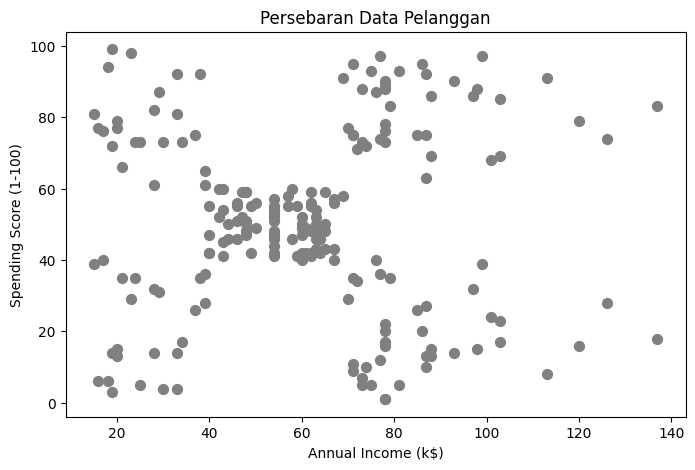

In [5]:
# Visualisasi Persebaran Data Awal
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], s=50, c='gray')
plt.title('Persebaran Data Pelanggan')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

In [6]:
# Penentuan Jumlah Cluster (k) Terbaik dengan Metode Elbow
sse = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)

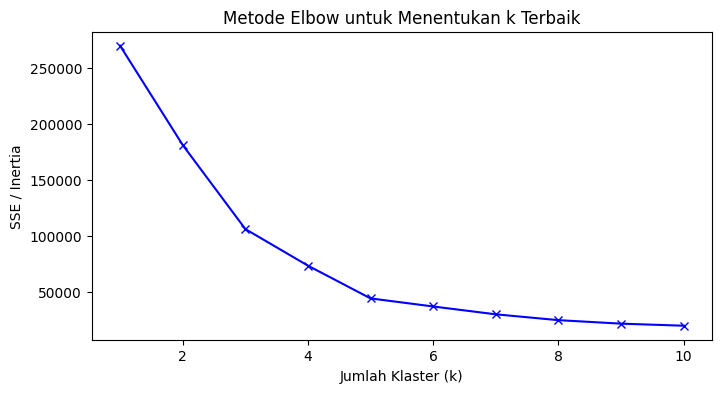

In [7]:
# Plot Metode Elbow
plt.figure(figsize=(8, 4))
plt.plot(K, sse, 'bx-')
plt.xlabel('Jumlah Klaster (k)')
plt.ylabel('SSE / Inertia')
plt.title('Metode Elbow untuk Menentukan k Terbaik')
plt.show()

In [8]:
# Konfirmasi dengan Silhouette Score
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f'k = {k}, Silhouette Score = {score:.4f}')

k = 2, Silhouette Score = 0.2969
k = 3, Silhouette Score = 0.4676
k = 4, Silhouette Score = 0.4932
k = 5, Silhouette Score = 0.5539
k = 6, Silhouette Score = 0.5398
k = 7, Silhouette Score = 0.5288
k = 8, Silhouette Score = 0.4548
k = 9, Silhouette Score = 0.4561
k = 10, Silhouette Score = 0.4411


In [9]:
# Membuat Model K-Means dengan k Optimum (k=5)
k_optimum = 5
kmeans = KMeans(n_clusters=k_optimum, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X)

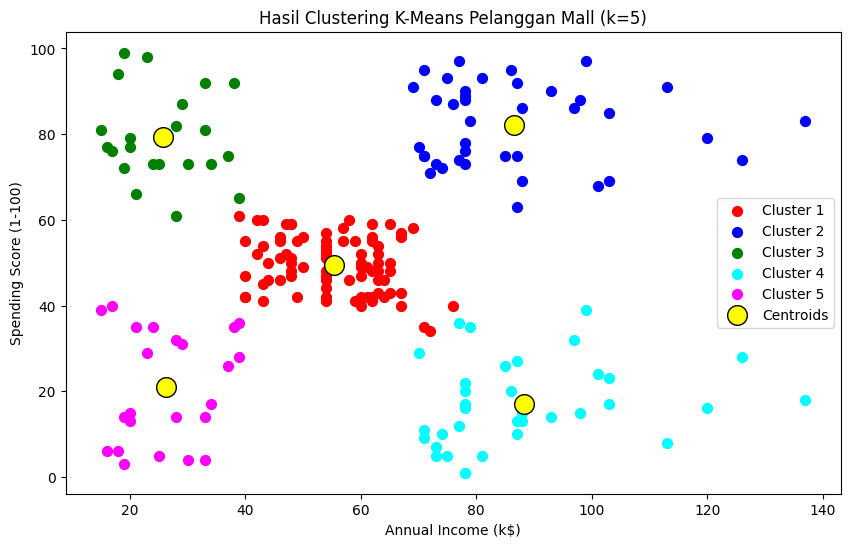

In [13]:
# Visualisasi Hasil Clustering dan Centroid
plt.figure(figsize=(10, 6))
colors = ['red', 'blue', 'green', 'cyan', 'magenta']
for i in range(k_optimum):
    plt.scatter(X[y_kmeans == i, 0], X[y_kmeans == i, 1], s=50, c=colors[i], label=f'Cluster {i+1}')

# Plot Centroid
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], s=200, c='yellow', edgecolors='black', label='Centroids')

plt.title('Hasil Clustering K-Means Pelanggan Mall (k=5)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

## **2. Tugas DBSCAN**
1. Buat dataset make_moons (1000 sampel, noise=0.05), lalu normalisasi.
2. Jalankan DBSCAN dengan eps=0.2, min_samples=5, hitung jumlah klaster & noise.
3. Evaluasi dengan metrik: Homogeneity, Completeness, V-measure, ARI, AMI, Silhouette.
4. Visualisasikan hasil DBSCAN (core sample = titik besar, non-core = titik kecil, noise = hitam).
5. Lakukan eksperimen:
    - eps = 0.05, 0.1, 0.3, 0.5
    - min_samples = 3, 10, 20
    - Catat perubahan klaster, noise, dan kualitas evaluasi.




In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn import metrics

In [16]:
# Buat dataset make_moons (1000 sampel, noise=0.05) & Normalisasi
X_raw, y_true = make_moons(n_samples=1000, noise=0.05, random_state=42)
X = StandardScaler().fit_transform(X_raw)


In [18]:
# Jalankan DBSCAN Baseline (eps=0.2, min_samples=5)
db_base = DBSCAN(eps=0.2, min_samples=5).fit(X)
labels_base = db_base.labels_

n_clusters_base = len(set(labels_base)) - (1 if -1 in labels_base else 0)
n_noise_base = list(labels_base).count(-1)

print(f"--- DBSCAN Baseline (eps=0.2, min_samples=5) ---")
print(f"Jumlah Klaster : {n_clusters_base}")
print(f"Jumlah Noise   : {n_noise_base}\n")


--- DBSCAN Baseline (eps=0.2, min_samples=5) ---
Jumlah Klaster : 2
Jumlah Noise   : 0



In [20]:
# Evaluasi Metrik untuk Baseline
print("--- Metrik Evaluasi Baseline ---")
print(f"Homogeneity                  : {metrics.homogeneity_score(y_true, labels_base):.3f}")
print(f"Completeness                 : {metrics.completeness_score(y_true, labels_base):.3f}")
print(f"V-measure                    : {metrics.v_measure_score(y_true, labels_base):.3f}")
print(f"Adjusted Rand Index (ARI)    : {metrics.adjusted_rand_score(y_true, labels_base):.3f}")
print(f"Adjusted Mutual Info (AMI)   : {metrics.adjusted_mutual_info_score(y_true, labels_base):.3f}")
print(f"Silhouette Coefficient       : {metrics.silhouette_score(X, labels_base):.3f}\n")

--- Metrik Evaluasi Baseline ---
Homogeneity                  : 1.000
Completeness                 : 1.000
V-measure                    : 1.000
Adjusted Rand Index (ARI)    : 1.000
Adjusted Mutual Info (AMI)   : 1.000
Silhouette Coefficient       : 0.391



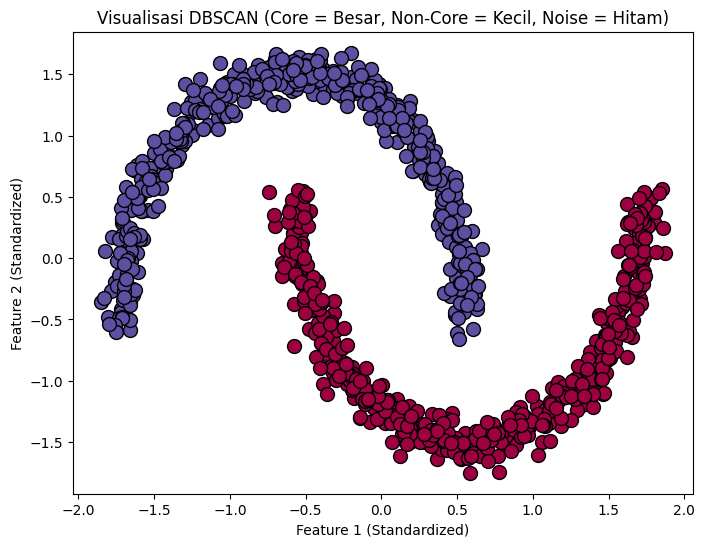

In [21]:
# Visualisasi Hasil DBSCAN Baseline
unique_labels = set(labels_base)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

plt.figure(figsize=(8, 6))
core_samples_mask = np.zeros_like(labels_base, dtype=bool)
core_samples_mask[db_base.core_sample_indices_] = True

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Noise diwarnai hitam
        col = [0, 0, 0, 1]

    class_member_mask = (labels_base == k)

    # Core sample (titik besar)
    xy = X[class_member_mask & core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=10)

    # Non-core / border sample (titik kecil)
    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=4)

plt.title('Visualisasi DBSCAN (Core = Besar, Non-Core = Kecil, Noise = Hitam)')
plt.xlabel('Feature 1 (Standardized)')
plt.ylabel('Feature 2 (Standardized)')
plt.show()


In [23]:
# Eksperimen Variasi Parameter eps dan min_samples
eps_values = [0.05, 0.1, 0.3, 0.5]
min_samples_values = [3, 10, 20]

results = []

for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms).fit(X)
        lbls = db.labels_

        n_clusters = len(set(lbls)) - (1 if -1 in lbls else 0)
        n_noise = list(lbls).count(-1)

        # Hitung metrik evaluasi
        if n_clusters > 1 and len(set(lbls)) > 1:
            sil = metrics.silhouette_score(X, lbls)
            ari = metrics.adjusted_rand_score(y_true, lbls)
            v_meas = metrics.v_measure_score(y_true, lbls)
        else:
            sil, ari, v_meas = np.nan, np.nan, np.nan

        results.append({
            'eps': eps,
            'min_samples': ms,
            'Jumlah Klaster': n_clusters,
            'Jumlah Noise': n_noise,
            'ARI': round(ari, 3) if not np.isnan(ari) else 'N/A',
            'V-Measure': round(v_meas, 3) if not np.isnan(v_meas) else 'N/A',
            'Silhouette': round(sil, 3) if not np.isnan(sil) else 'N/A'
        })

# Menampilkan hasil eksperimen dalam bentuk DataFrame
df_results = pd.DataFrame(results)
display(df_results)

,eps,min_samples,Jumlah Klaster,Jumlah Noise,ARI,V-Measure,Silhouette
0,0.05,3,69,186,0.03,0.257,0.113
1,0.05,10,3,970,0.002,0.049,-0.294
2,0.05,20,0,1000,N/A,N/A,N/A
3,0.10,3,2,14,0.972,0.943,0.252
4,0.10,10,7,57,0.523,0.571,0.162
5,0.10,20,6,850,0.017,0.155,-0.36
6,0.30,3,2,0,1.0,1.0,0.391
7,0.30,10,2,0,1.0,1.0,0.391
8,0.30,20,2,0,1.0,1.0,0.391
9,0.50,3,2,0,1.0,1.0,0.391
